# **Assignment 03**
Author: Celina Binder

## Dataset for all the exercises in this assignment

In [1]:
from sklearn.datasets import fetch_20newsgroups
cats = ['sci.space', 'comp.graphics', 'rec.sport.hockey', 'alt.atheism']
data = fetch_20newsgroups(subset='train', categories=cats, remove=('headers', 'footers', 'quotes'))
X_text, y, target_names = data.data, data.target, data.target_names

# Exercise 1 Bag of Words & TF-IDF
In the first exercise, compare the Bag of Words and TF-IDF representations for the 20 news
groups text dataset by taking a look at the similarities between the 5 news categories.
### Tasks
• Fit CountVectorizer (Bag of Words) and TfidfVectorizer (TF-IDF). Make sure to remove the stopwords.  
• Top terms per class based on TF-IDF: For each category, compute the top-10 terms by average TF-IDF over the whole corpus.  
• Similarity: Pick a random message for each category. For those messages, compute the cosine similarity of the TF-IDF and BoW repesentations. Compare which representation separates categories better.  
• Discuss in exercise: When does TF-IDF outperform BoW?

### Imports

In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import spacy
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# initialize vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# claculating TF-IDF
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt


### Fit CountVectorizer (Bag of Words) and TfidfVectorizer (TF-IDF)

In [4]:
# initialize vectorizer
vectorizer_bow = CountVectorizer(stop_words='english')

vectorizer_tfidf = TfidfVectorizer(stop_words='english')

In [5]:
bow = vectorizer_bow.fit_transform(X_text)
tfidf = vectorizer_tfidf.fit_transform(X_text)

In [6]:
# View vocabulary
vectorizer_bow.vocabulary_

{'fact': 10763,
 'direct': 8989,
 'ire': 14348,
 'proper': 20525,
 'target': 25069,
 'ingoring': 13938,
 'nasa': 17711,
 'altogether': 3660,
 'rocket': 22101,
 'commercial': 7042,
 'launch': 15465,
 'vechicle': 26834,
 'conestoga': 7318,
 'flying': 11301,
 'comet': 7005,
 'payload': 19222,
 'simply': 23353,
 'primary': 20333,
 'customer': 8085,
 'believe': 4927,
 'sdio': 22782,
 'small': 23560,
 'advertising': 3291,
 'space': 23789,
 'sold': 23694,
 'owners': 18893,
 'darn': 8245,
 'addition': 3194,
 'anonymous': 3883,
 'observers': 18341,
 'reason': 21199,
 'startled': 24171,
 'deal': 8345,
 'news': 17930,
 'twice': 26124,
 'think': 25409,
 'fair': 10795,
 'starts': 24173,
 'having': 12742,
 'hissy': 13015,
 'fit': 11160,
 'bothered': 5437,
 'use': 26611,
 'conditional': 7300,
 'tense': 25246,
 'suggests': 24633,
 'approved': 4039,
 'really': 21188,
 'makes': 16322,
 'islanders': 14406,
 'better': 5035,
 'shot': 23203,
 'couldn': 7734,
 'beat': 4855,
 'whalers': 27505,
 'games': 11750

In [7]:
vectorizer_tfidf.vocabulary_

{'fact': 10763,
 'direct': 8989,
 'ire': 14348,
 'proper': 20525,
 'target': 25069,
 'ingoring': 13938,
 'nasa': 17711,
 'altogether': 3660,
 'rocket': 22101,
 'commercial': 7042,
 'launch': 15465,
 'vechicle': 26834,
 'conestoga': 7318,
 'flying': 11301,
 'comet': 7005,
 'payload': 19222,
 'simply': 23353,
 'primary': 20333,
 'customer': 8085,
 'believe': 4927,
 'sdio': 22782,
 'small': 23560,
 'advertising': 3291,
 'space': 23789,
 'sold': 23694,
 'owners': 18893,
 'darn': 8245,
 'addition': 3194,
 'anonymous': 3883,
 'observers': 18341,
 'reason': 21199,
 'startled': 24171,
 'deal': 8345,
 'news': 17930,
 'twice': 26124,
 'think': 25409,
 'fair': 10795,
 'starts': 24173,
 'having': 12742,
 'hissy': 13015,
 'fit': 11160,
 'bothered': 5437,
 'use': 26611,
 'conditional': 7300,
 'tense': 25246,
 'suggests': 24633,
 'approved': 4039,
 'really': 21188,
 'makes': 16322,
 'islanders': 14406,
 'better': 5035,
 'shot': 23203,
 'couldn': 7734,
 'beat': 4855,
 'whalers': 27505,
 'games': 11750

-> vectorizer output is a compressed sparse row matrix, which is done to improve memory efficiency

### Top terms per class based on TF-IDF

In [8]:
# calculating TF-IDF with pandas+
tfidf_matrix = vectorizer_tfidf.fit_transform(X_text)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer_tfidf.get_feature_names_out())
print(tfidf_df)

       00       000  0000  00000  000000  000005102000  000062david42  \
0     0.0  0.000000   0.0    0.0     0.0           0.0            0.0   
1     0.0  0.000000   0.0    0.0     0.0           0.0            0.0   
2     0.0  0.000000   0.0    0.0     0.0           0.0            0.0   
3     0.0  0.000000   0.0    0.0     0.0           0.0            0.0   
4     0.0  0.000000   0.0    0.0     0.0           0.0            0.0   
...   ...       ...   ...    ...     ...           ...            ...   
2252  0.0  0.000000   0.0    0.0     0.0           0.0            0.0   
2253  0.0  0.045212   0.0    0.0     0.0           0.0            0.0   
2254  0.0  0.000000   0.0    0.0     0.0           0.0            0.0   
2255  0.0  0.000000   0.0    0.0     0.0           0.0            0.0   
2256  0.0  0.000000   0.0    0.0     0.0           0.0            0.0   

      000100255pixel  00041032  0004136  ...  zurich  zus  zvi  zwaartepunten  \
0                0.0       0.0      0.0  .

**AI Use:** Claude  
*Prompt:* tell me how to fix this: # calculating TF-IDF with pandas+
tfidf_matrix = vectorizer_tfidf.fit_transform(X_text)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer_tfidf.get_feature_names_out())
print(tfidf_df) in order to get the top ten per categorie

In [9]:
# Get average TF-IDF score per term, grouped by category
tfidf_matrix = vectorizer_tfidf.fit_transform(X_text)
feature_names = vectorizer_tfidf.get_feature_names_out()

for i, category in enumerate(target_names):
    # Select only rows belonging to this category
    indices = np.where(y == i)[0]
    class_tfidf = tfidf_matrix[indices]
    
    # Average TF-IDF across all documents in this class
    mean_scores = class_tfidf.mean(axis=0).A1  # .A1 flattens the matrix to 1D array
    top10_idx = mean_scores.argsort()[::-1][:10]
    
    print(f"\n--- {category} ---")
    for idx in top10_idx:
        print(f"  {feature_names[idx]}: {mean_scores[idx]:.4f}")


--- alt.atheism ---
  god: 0.0351
  people: 0.0259
  don: 0.0235
  think: 0.0210
  just: 0.0188
  religion: 0.0183
  say: 0.0180
  atheism: 0.0168
  does: 0.0156
  islam: 0.0139

--- comp.graphics ---
  graphics: 0.0315
  thanks: 0.0248
  image: 0.0204
  files: 0.0202
  file: 0.0193
  know: 0.0179
  program: 0.0170
  does: 0.0161
  looking: 0.0154
  windows: 0.0151

--- rec.sport.hockey ---
  game: 0.0361
  team: 0.0313
  hockey: 0.0274
  games: 0.0218
  play: 0.0214
  season: 0.0209
  players: 0.0209
  nhl: 0.0181
  year: 0.0173
  think: 0.0152

--- sci.space ---
  space: 0.0454
  nasa: 0.0208
  like: 0.0165
  launch: 0.0149
  moon: 0.0148
  just: 0.0148
  orbit: 0.0146
  earth: 0.0127
  shuttle: 0.0124
  think: 0.0123


### Similarity: Pick a random message for each category 
For those messages, compute the cosine similarity of the TF-IDF and BoW repesentations. Compare which representation separates categories better.  

**AI Use:** Claude  
*Prompt:* use the following to do the following: Similarity: Pick a random message for each category. For those messages, compute the cosine similarity of the TF-IDF and BoW repesentations. Compare which representation separates categories better.
plt.figure(figsize=(10, 8))
sns.heatmap(tfidf_df.corr(), annot=True, cmap='coolwarm', square=True)
plt.title('TF-IDF Heatmap')
plt.show()

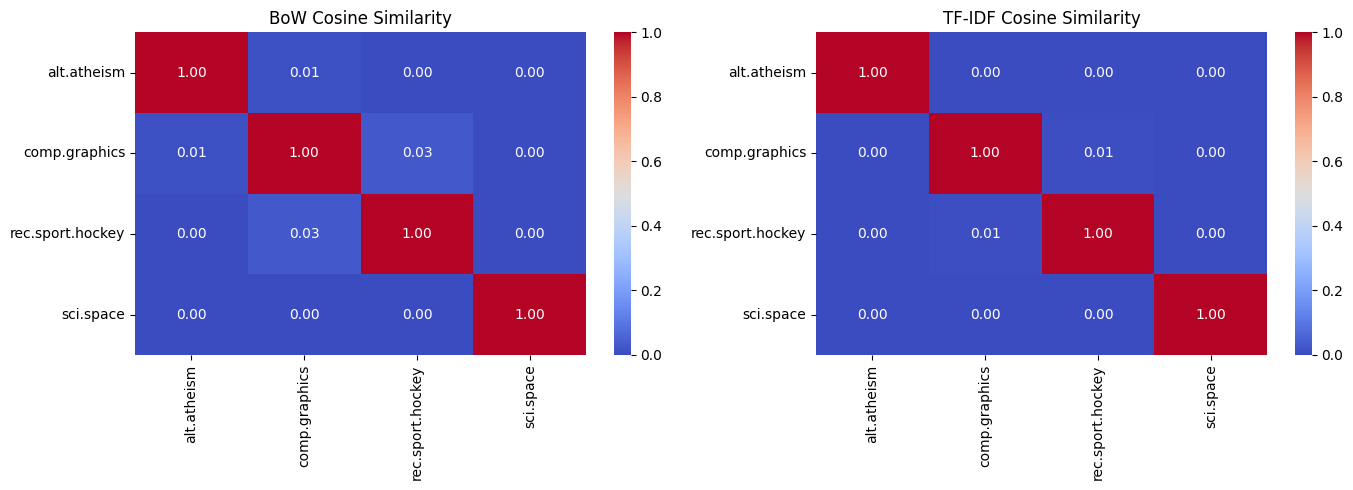

In [10]:
# Pick one random message per category
np.random.seed(42)
sample_indices = [np.random.choice(np.where(y == i)[0]) for i in range(len(target_names))]

# Re-fit both vectorizers with stopwords removed
bow_matrix    = CountVectorizer(stop_words='english').fit_transform(X_text)
tfidf_matrix  = TfidfVectorizer(stop_words='english').fit_transform(X_text)

# Extract the sample rows
bow_samples   = bow_matrix[sample_indices]
tfidf_samples = tfidf_matrix[sample_indices]

# Compute 4x4 cosine similarity matrices
sim_bow   = cosine_similarity(bow_samples)
sim_tfidf = cosine_similarity(tfidf_samples)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sim, title in zip(axes, [sim_bow, sim_tfidf], ["BoW Cosine Similarity", "TF-IDF Cosine Similarity"]):
    sns.heatmap(sim, annot=True, fmt=".2f", cmap="coolwarm",
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Discuss in exercise: When does TF-IDF outperform BoW?

TF-IDFoutperforms BoW whenever the documents share many common but uninformative words like "said", "also". As BoW counts every word with equal importance meaningless words that are frequent will get high similarity scores. TF-IDF on the other hand uses inverse document frequency, therefor only distinctive words get a high score. 

The heatmap shows that the TF-IDF is slightly better at separating the categories.

# Exercise 2 N-Grams and Feature Explosion
Generate example n-grams and briefly examine why their number grows rapidly and how this
affects real-world NLP.
### Tasks
- Generate all bigrams and trigrams of the sentence ”The quick brown fox jumps over the lazy dog”.  
- Discuss the concept of feature explosion:
    -  How many possible bigrams exist in a vocabulary of size V?
    - Why does this become a problem in real-world NLP?
    - Discuss in exercise: Considering the problems, what are the advantages?


### Imports

In [11]:
from sklearn.feature_extraction.text import CountVectorizer


### Generation of example n-grams
*Source:* https://github.com/practical-nlp/practical-nlp-code/blob/master/Ch3/03_Bag_of_N_Grams.ipynb

In [12]:
documents = ["Cat bites child.", "Child bites cat.", "Cat eats meat.", "Child eats food."]

processed_docs = [doc.lower().replace(".","") for doc in documents]
processed_docs

['cat bites child', 'child bites cat', 'cat eats meat', 'child eats food']

In [13]:
#Ngram vectorization example with count vectorizer and uni, bi, trigrams
count_vect = CountVectorizer(ngram_range=(1,3))

#Build a BOW representation for the corpus
bow_rep = count_vect.fit_transform(processed_docs)

#Look at the vocabulary mapping
print("Defined vocabulary: ", count_vect.vocabulary_)

#see the BOW rep for first 2 documents
print("BoW representation for 'cat bites child': ", bow_rep[0].toarray())
print("BoW representation for 'child bites cat': ",bow_rep[1].toarray())

#Get the representation using this vocabulary, for a new text
temp = count_vect.transform(["cat and cat are friends"])

print("Bow representation for 'cat and cat are friends':", temp.toarray())

Defined vocabulary:  {'cat': 3, 'bites': 0, 'child': 8, 'cat bites': 4, 'bites child': 2, 'cat bites child': 5, 'child bites': 9, 'bites cat': 1, 'child bites cat': 10, 'eats': 13, 'meat': 17, 'cat eats': 6, 'eats meat': 15, 'cat eats meat': 7, 'food': 16, 'child eats': 11, 'eats food': 14, 'child eats food': 12}
BoW representation for 'cat bites child':  [[1 0 1 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0]]
BoW representation for 'child bites cat':  [[1 1 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0]]
Bow representation for 'cat and cat are friends': [[0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


### Generate all bigrams and trigrams 
of the sentence ”The quick brown fox jumps over the lazy dog”  
*Source:* https://www.geeksforgeeks.org/nlp/n-gram-in-nlp/

In [14]:
def generate_ngrams(text, n):
    tokens = text.split()
    ngrams = [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]
    return ngrams


text = "The quick brown fox jumps over the lazy dog"

unigrams = generate_ngrams(text, 1)
bigrams = generate_ngrams(text, 2)
trigrams = generate_ngrams(text, 3)

print("Unigrams:", unigrams)
print("Bigrams:", bigrams)
print("Trigrams:", trigrams)

Unigrams: [('The',), ('quick',), ('brown',), ('fox',), ('jumps',), ('over',), ('the',), ('lazy',), ('dog',)]
Bigrams: [('The', 'quick'), ('quick', 'brown'), ('brown', 'fox'), ('fox', 'jumps'), ('jumps', 'over'), ('over', 'the'), ('the', 'lazy'), ('lazy', 'dog')]
Trigrams: [('The', 'quick', 'brown'), ('quick', 'brown', 'fox'), ('brown', 'fox', 'jumps'), ('fox', 'jumps', 'over'), ('jumps', 'over', 'the'), ('over', 'the', 'lazy'), ('the', 'lazy', 'dog')]


### Discuss the concept of feature explosion:


##### **How many possible bigrams exist in a vocabulary of size V?**
*Answer:* For a vocabulary of size V, there are V² possible bigrams and V³ possible trigrams.


**AI Use:** Claude  
*Prompt:* using my explanation: If we have a vocabulary of size V wthere will be V² bigrams and V³ trigrams. As most of them are probably not going to actually be present, we get a sparse matrix. write me the code to make the effect visible

In [ ]:
V = len(vectorizer_bow.vocabulary_)  # vocabulary size from Exercise 1
unigrams = V
bigrams = V ** 2
trigrams = V ** 3

print(f"Vocabulary size (V):     {V:,}")
print(f"Possible unigrams (V):   {unigrams:,}")
print(f"Possible bigrams (V²):   {bigrams:,}")
print(f"Possible trigrams (V³):  {trigrams:,}")

Vocabulary size (V):     28,209
Possible unigrams (V):   28,209
Possible bigrams (V²):   795,747,681
Possible trigrams (V³):  22,447,246,333,329


##### **Why does this become a problem in real-world NLP?**

In the real world we have much bigger sets of words which results in really big numbers (up to 10 billions) of possible features for the bi- and trigrams.

- we don't have the memory to store such a big sparse matrix
- most possibilities won't appear-> making the majority of feature values to zero and the matrix signal therefor to almost zero
- we have a high risk of overfitting as the model tries to memorize the data in such high dimensions

**AI Use:** Claude  
*Prompt:* using my notes formulate a lot nicer and suggest what I might have forgotten: Bow keept context, n-grams take negation into consideratioon, n-grams need no training

##### **Discuss in exercise: Considering the problems, what are the advantages?**

- Context preservation: bigrams like "not good" or "ice hockey" carry meaning that unigrams completely lose - BoW would treat "not" and "good" as independent signals
- Phrase detection: domain-specific terms like "machine learning", "neural network", or "penalty shot" are only meaningful as a unit
- Improved classification: for tasks like sentiment analysis, n-grams significantly outperform unigrams because negation and multi-word expressions matter
- No training needed: unlike Word2Vec or FastText, n-gram features require no neural training and are fully interpretable

# Exercise 3 Word2Vec Concepts: CBOW and Skip-Gram
Revisit how Word2Vec learns word relationships by predicting contexts. Demonstrate the two
variants by forming training pairs from a simple sentence.
### Tasks
• Explain in your own words the difference between CBOW and Skip-Gram.  
• Given the sentence: ”The quick brown fox jumps over the lazy dog.” and using a context window size of 2, list the (input → target) training pairs generated by CBOW and Skip-Gram

### Imports

In [15]:
pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [16]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [18]:
from gensim.models import Word2Vec
import gensim
from nltk.tokenize import sent_tokenize, word_tokenize
#nltk.download('punkt_tab')
import warnings

warnings.filterwarnings(action='ignore')

### Demonstrate the two Word2Vec variants by forming training pairs from a simple sentence
*Source:* https://www.geeksforgeeks.org/python/python-word-embedding-using-word2vec/

In [19]:
# CBOW model
model1 = gensim.models.Word2Vec(data, min_count=1,
                                vector_size=100, window=5)


In [20]:
# Skip-gram model
model2 = gensim.models.Word2Vec(data, min_count=1, vector_size=100,
                                window=5, sg=1)

In [25]:
# Defining simple training sentence
sentences = [["the", "child", "sat", "on", "the", "bank"],
             ["the", "fish", "sat", "on", "the", "log"]]

In [26]:
# Forming pairs for CBOW
pairs_cbow = []
for sentence in sentences:
    for i in range(1, len(sentence) - 1):
        context = [sentence[i - 1], sentence[i + 1]]
        target = sentence[i]
        pairs_cbow.append((context, target))

# Forming pairs for Skip-gram
pairs_skipgram = []
for sentence in sentences:
    for i in range(1, len(sentence) - 1):
        target = sentence[i]
        context = [sentence[i - 1], sentence[i + 1]]
        pairs_skipgram.append((target, context))

print("CBOW pairs:")
for context, target in pairs_cbow:
    print(f"Context: {context} -> Target: {target}")
print("\nSkip-gram pairs:")
for target, context in pairs_skipgram:
    print(f"Target: {target} -> Context: {context}")

CBOW pairs:
Context: ['the', 'sat'] -> Target: child
Context: ['child', 'on'] -> Target: sat
Context: ['sat', 'the'] -> Target: on
Context: ['on', 'bank'] -> Target: the
Context: ['the', 'sat'] -> Target: fish
Context: ['fish', 'on'] -> Target: sat
Context: ['sat', 'the'] -> Target: on
Context: ['on', 'log'] -> Target: the

Skip-gram pairs:
Target: child -> Context: ['the', 'sat']
Target: sat -> Context: ['child', 'on']
Target: on -> Context: ['sat', 'the']
Target: the -> Context: ['on', 'bank']
Target: fish -> Context: ['the', 'sat']
Target: sat -> Context: ['fish', 'on']
Target: on -> Context: ['sat', 'the']
Target: the -> Context: ['on', 'log']


### Explain in your own words the difference between CBOW and Skip-Gram
CBOW takes multiple context words as input and predicts the center word. It averages the surrounding words to make one prediction, which makes it faster and works well when there is plenty of data.
Skip-Gram does the opposite - it takes one center word as input and predicts the surrounding context words. This generates more training pairs per word, which makes it slower but significantly better on small datasets and for rare words.

### Training pairs on sample sentence 
Given the sentence: ”The quick brown fox jumps over the lazy dog.” and using a context window size of 2, list the (input → target) training pairs generated by CBOW and Skip-Gram

In [1]:
# Defining the sample sentence
sample_sentence = "The quick brown fox jumps over the lazy dog"

# Tokenize the sample sentence
tokens = sample_sentence.split()
print("Tokens:", tokens)

Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']


In [2]:
# Forming pairs for CBOW
pairs_cbow = []
for i in range(2, len(tokens) - 2): # context window of 2
    context = [tokens[i - 2], tokens[i + 2]]
    target = tokens[i]
    pairs_cbow.append((context, target))

# Forming pairs for Skip-gram
pairs_skipgram = []
for i in range(2, len(tokens) - 2): # context window of 2
    target = tokens[i]
    context = [tokens[i - 2], tokens[i + 2]]
    pairs_skipgram.append((target, context))

print("CBOW pairs:")
for context, target in pairs_cbow:
    print(f"Input: {context} -> Target: {target}")
print("\nSkip-gram pairs:")
for target, context in pairs_skipgram:
    print(f"Target: {target} -> Input: {context}")

CBOW pairs:
Input: ['The', 'jumps'] -> Target: brown
Input: ['quick', 'over'] -> Target: fox
Input: ['brown', 'the'] -> Target: jumps
Input: ['fox', 'lazy'] -> Target: over
Input: ['jumps', 'dog'] -> Target: the

Skip-gram pairs:
Target: brown -> Input: ['The', 'jumps']
Target: fox -> Input: ['quick', 'over']
Target: jumps -> Input: ['brown', 'the']
Target: over -> Input: ['fox', 'lazy']
Target: the -> Input: ['jumps', 'dog']


# Exercise 4 CBOW vs Skip-Gram (Train & Probe)
You will train both Word2Vec architectures on the same corpus and compare the semantic neighborhoods they produce. This highlights how each model behaves on small datasets and which one captures meaning more reliably.
### Tasks
• Preprocess: tokenize with gensim.simple preprocess, remove stopwords.   
• Train CBOW (sg=0) and Skip-Gram (sg=1) with modest settings (e.g., vector size=100,
window=5, min count=5, epochs=10)   
• For 3 query words (e.g., space, graphics, hockey), list top-10 most similar words for each
model. Compare qualitatively (topics? noise?).    
• Discuss in exercise: Which works better on small data? Why?

### Imports

In [40]:
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from gensim.models import Word2Vec

### Preprocess: tokenize with gensim.simple preprocess, remove stopwords

In [38]:
tokenized = []
for doc in X_text:
    for sentence in doc.split('.'):
        words = simple_preprocess(sentence, deacc=True)
        words = [w for w in words if w not in STOPWORDS]  # remove stopwords
        tokenized.append(words)

print(tokenized[:5])

[['fact', 'direct', 'ire', 'proper', 'target', 'ingoring', 'nasa', 'altogether'], ['rocket', 'commercial', 'launch', 'vechicle', 'conestoga', 'flying', 'comet', 'payload'], ['nasa', 'simply', 'primary', 'customer'], ['believe', 'sdio', 'small', 'payload'], ['advertising', 'space', 'sold', 'owners', 'rocket', 'darn']]


### Train CBOW (sg=0) and Skip-Gram (sg=1) 
with modest settings (e.g., vector size=100,
window=5, min count=5, epochs=10) 

*Source:* https://www.geeksforgeeks.org/nlp/continuous-bag-of-words-cbow-in-nlp/

**AI Use:** Claude  
*Prompt:* how can I transform this into a format suitable for Keras: tokenized = []
for doc in X_text:
    for sentence in doc.split('.'):
        words = simple_preprocess(sentence, deacc=True)
        words = [w for w in words if w not in STOPWORDS]  # remove stopwords
        tokenized.append(words)

print(tokenized[:5])

In [41]:
# transform python list of tokenized sentences into a format suitable for Word2Vec (into a Keras object)
# Train CBOW (sg=0)
cbow_model = Word2Vec(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=5,
    epochs=10,
    sg=0  # CBOW
)

# Train Skip-Gram (sg=1)
skipgram_model = Word2Vec(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=5,
    epochs=10,
    sg=1  # Skip-Gram
)

### For 3 query words (e.g., space, graphics, hockey), list top-10 most similar words for each model
Compare qualitatively (topics? noise?)

**AI Use:** Claude  
*Prompt:* how can I compare similar words in the easiest way possible

In [43]:
# Compare similar words for a few query terms
query_words = ['space', 'graphics', 'hockey']

for word in query_words:
    print(f"\n--- '{word}' | CBOW ---")
    if word in cbow_model.wv:
        for w, score in cbow_model.wv.most_similar(word, topn=10):
            print(f"  {w}: {score:.4f}")
    else:
        print("  (not in vocabulary)")

    print(f"\n--- '{word}' | Skip-Gram ---")
    if word in skipgram_model.wv:
        for w, score in skipgram_model.wv.most_similar(word, topn=10):
            print(f"  {w}: {score:.4f}")
    else:
        print("  (not in vocabulary)")


--- 'space' | CBOW ---
  nasa: 0.9812
  shuttle: 0.9744
  launch: 0.9722
  station: 0.9674
  technology: 0.9654
  research: 0.9585
  institute: 0.9422
  national: 0.9352
  science: 0.9287
  mission: 0.9245

--- 'space' | Skip-Gram ---
  nasa: 0.6375
  station: 0.6236
  aerospace: 0.6144
  exploration: 0.6052
  larc: 0.6037
  astronaut: 0.6006
  llnl: 0.5994
  federal: 0.5969
  missions: 0.5933
  gov: 0.5924

--- 'graphics' | CBOW ---
  pc: 0.9832
  package: 0.9810
  mac: 0.9793
  file: 0.9737
  files: 0.9730
  amiga: 0.9728
  unix: 0.9705
  library: 0.9682
  windows: 0.9674
  dos: 0.9670

--- 'graphics' | Skip-Gram ---
  programming: 0.7912
  library: 0.7614
  animation: 0.7603
  msdos: 0.7574
  silicon: 0.7552
  radiosity: 0.7514
  raytracing: 0.7501
  gems: 0.7420
  exponent: 0.7416
  ch: 0.7396

--- 'hockey' | CBOW ---
  league: 0.9704
  nhl: 0.9486
  team: 0.9268
  players: 0.9141
  teams: 0.9035
  champs: 0.8951
  playoff: 0.8831
  canadian: 0.8820
  games: 0.8696
  played: 0.864

**AI Use:** Claude  
*Prompt:* use the following notes and formulate nicer: skip gram better for small data, skip gram makes more pairs than CBOW, skipgram has denser training signal

### Discuss in exercise: Which works better on small data? Why?

Skip-Gram works better on small data.

For each word, Skip-Gram generates more training pairs than CBOW, with window size 5, one word creates up to 10 pairs. CBOW averages all context words into one update, which means less learning signal overall. Rare words also benefit more from Skip-Gram, since they get dedicated training updates instead of being averaged away into the context. On large corpora CBOW catches up due to sheer data volume, but on a small dataset like 20newsgroups, Skip-Gram's denser training signal produces more meaningful and topically coherent word neighborhoods.

# Exercise 5 FastText & Embedding Visualization
FastText enriches word embeddings with subword information, improving representations for
rare words. You will train a model and visualize its embeddings to observe clusters and outliers
in 2D space.
### Tasks
• Train FastText on the same sentences with subword information (min n=3, max n=6).  
• Build a matrix of word vectors and reduce to 2D via PCA and t-SNE.  
• Plot points and label them based on category. Interpret clusters and outliers.   
• Pick 15–30 representative words across categories to have a more detailed comparison.  
**Process and plot them as well**

### Imports

**AI Use:** Claude  
*Prompt:* how can i fix this error: Collecting fasttext   Downloading fasttext-0.9.3.tar.gz (73 kB)   Installing build dependencies: started   Installing build dependencies: finished with status 'done'   Getting requirements to build wheel: started   Getting requirements to build wheel: finished with status 'done'   Preparing metadata (pyproject.toml): started   Preparing metadata (pyproject.toml): finished with status 'done' Collecting pybind11>=2.2 (from fasttext)   Using cached pybind11-3.0.2-py3-none-any.whl.metadata (10 kB) Requirement already satisfied: setuptools>=0.7.0 in c:\Users\Celina Binder\OneDrive - FH OOe\Desktop\FH Hagenberg\4_Semester_FH_Hagenberg\NLP4IL\NLP4IL.venv\Lib\site-packages (from fasttext) (82.0.1) Requirement already satisfied: numpy in c:\Users\Celina Binder\OneDrive - FH OOe\Desktop\FH Hagenberg\4_Semester_FH_Hagenberg\NLP4IL\NLP4IL.venv\Lib\site-packages (from fasttext) (2.4.3) Using cached pybind11-3.0.2-py3-none-any.whl (310 kB) Building wheels for collected packages: fasttext   Building wheel for fasttext (pyproject.toml): started   Building wheel for fasttext (pyproject.toml): finished with status 'error' Failed to build fasttext Note: you may need to restart the kernel to use updated packages. 

  error: subprocess-exited-with-error      × Building wheel for fasttext (pyproject.toml) did not run successfully.   │ exit code: 1   ╰─> [136 lines of output]       C:\Users\Celina Binder\AppData\Local\Temp\pip-build-env-cpys4ic6\overlay\Lib\site-packages\setuptools\dist.py:599: SetuptoolsDeprecationWarning: Invalid dash-separated key 'description-file' in 'metadata' (setup.cfg), please use the underscore name 'description_file' instead.       !!                      ********************************************************************************               Usage of dash-separated 'description-file' will not be supported in future               versions. Please use the underscore name 'description_file' instead.               (Affected: fasttext).                      Available configuration options are listed in:               https://setuptools.pypa.io/en/latest/userguide/declarative_config.html                      This deprecation is overdue, please update your project and remove deprecated               calls to avoid build errors in the future.                      See https://github.com/pypa/setuptools/discussions/5011 for details.               ********************************************************************************              !!         opt = self._enforce_underscore(opt, section)       C:\Users\Celina Binder\AppData\Local\Temp\pip-build-env-cpys4ic6\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.

...

error: failed-wheel-build-for-install  × Failed to build installable wheels for some pyproject.toml based projects ╰─> fasttext

Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...

In [45]:
pip install fasttext

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pybind11-3.0.2-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.2-py3-none-any.whl (310 kB)
Failed to build fasttext
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for fasttext (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [136 lines of output]
      C:\Users\Celina Binder\AppData\Local\Temp\pip-build-env-cpys4ic6\overlay\Lib\site-packages\setuptools\dist.py:599: SetuptoolsDeprecationWarning: Invalid dash-separated key 'description-file' in 'metadata' (setup.cfg), please use the underscore name 'description_file' instead.
      !!
      
              ********************************************************************************
              Usage of dash-separated 'description-file' will not be supported in future
              versions. Please use the underscore name 'description_file' instead.
              (Affected: fasttext).
      
              Available configuration options are listed in:
              https://setuptools.pypa.io/en/latest/userguide/declarative_config.html
      
              This deprecation is overdue, please update your project and rem

In [48]:
# as fasttext did not work I decided to use gensims FastText implementation instead
from gensim.models import FastText
import os

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np


### Train FastText on the same sentences with subword information (min n=3, max n=6)
*Source:* https://colab.research.google.com/github/pythonandml/dlbook/blob/master/content/word_embeddings/fasttext.ipynb

In [47]:
# Train FastText model
ft_model = FastText(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=5,
    epochs=10,
    min_n=3,  # minimum subword length
    max_n=6   # maximum subword length
)

### Build a matrix of word vectors and reduce to 2D via PCA and t-SNE.  

**AI Use:** Claude  
*Prompt:* give me an idea on how this could be done with the following model: # Train FastText model
ft_model = FastText(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=5,
    epochs=10,
    min_n=3,  # minimum subword length
    max_n=6   # maximum subword length
)v

In [ ]:
# Build the matrix — one row per word in the vocabulary
words = list(ft_model.wv.index_to_key)  # all words in vocabulary
word_vectors = np.array([ft_model.wv[w] for w in words])  # shape: (vocab_size, vector_size)

print(f"Matrix shape: {word_vectors.shape}")

Matrix shape: (6874, 100)


In [ ]:
# PCA reduction
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(word_vectors)  # shape: (top_n, 2)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# t-SNE reduction (use PCA output as init for stability)
tsne = TSNE(
    n_components=2,
    perplexity=30,      # increase if you have more points
    max_iter=1000,
    random_state=42,
    init='pca'          # more stable than random init
)
tsne_result = tsne.fit_transform(word_vectors)  # shape: (top_n, 2)

PCA explained variance: 69.53%


### Plot points and label them based on category. Interpret clusters and outliers

**AI Use:** Claude  
*Prompt:* Give me an idea on how to make a nice plot and tell be how to make the correct labels

In [52]:
# Define category keyword lists
category_keywords = {
    'sci.space':        ['space', 'nasa', 'orbit', 'shuttle', 'moon', 'earth', 'launch', 'satellite'],
    'comp.graphics':    ['graphics', 'image', 'pixel', 'render', 'color', 'screen', 'display', 'format'],
    'rec.sport.hockey': ['hockey', 'game', 'team', 'player', 'score', 'season', 'league', 'win'],
    'alt.atheism':      ['atheism', 'god', 'religion', 'belief', 'church', 'bible', 'faith', 'moral']
}

In [53]:
# Assign each word a category label
def assign_category(word):
    for category, keywords in category_keywords.items():
        if word in keywords:
            return category
    return 'other'

labels = [assign_category(w) for w in words]

In [ ]:
# Define colors per category
color_map = {
    'sci.space':        'blue',
    'comp.graphics':    'green',
    'rec.sport.hockey': 'red',
    'alt.atheism':      'orange',
    'other':            'lightgrey'
}
colors = [color_map[l] for l in labels]

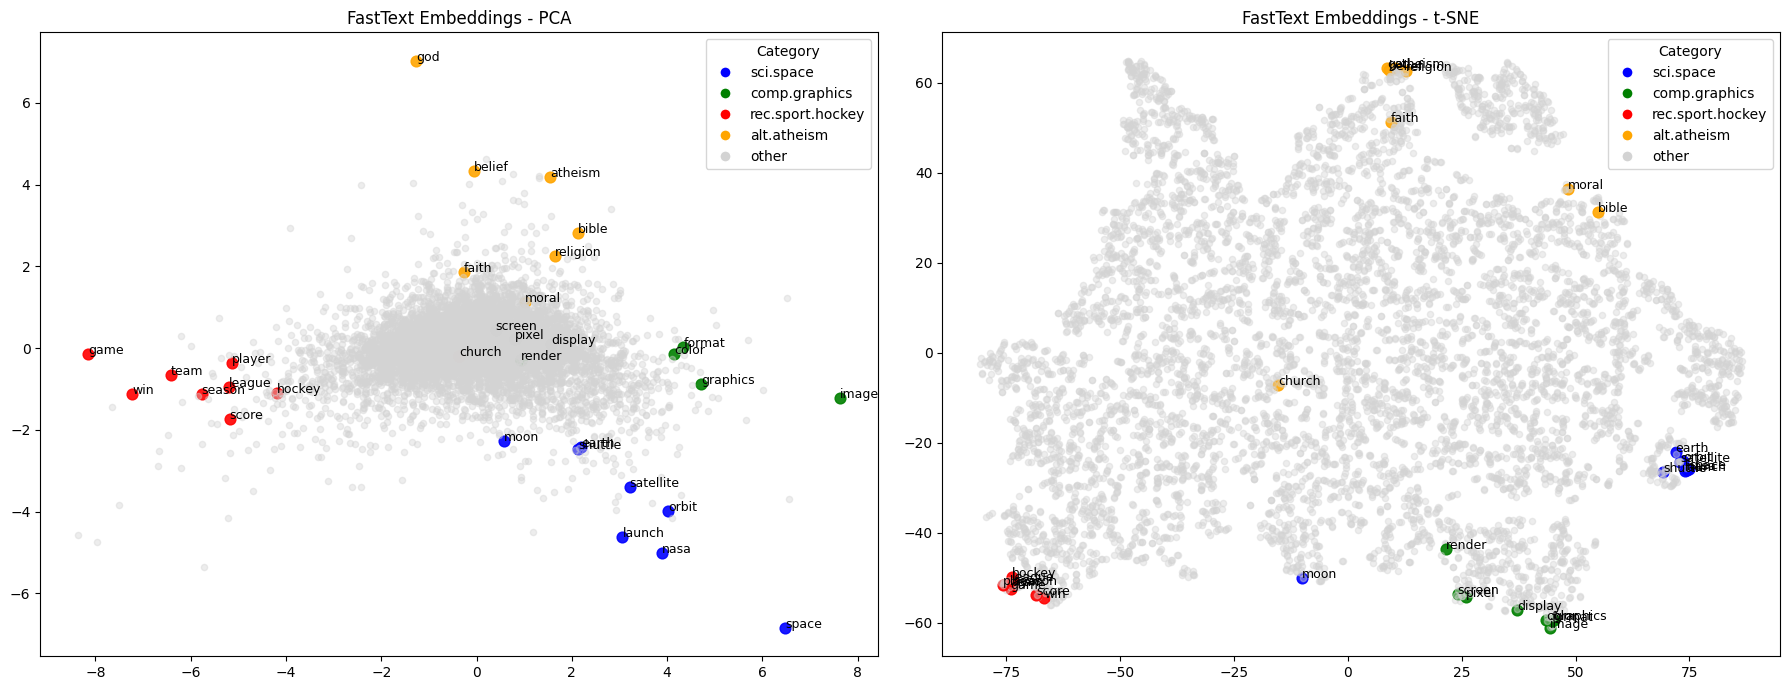

In [93]:
# plot PCA and t-SNE side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, result, title in zip(axes, [pca_result, tsne_result], ["PCA", "t-SNE"]):
    # plot 'other' words first so category words appear on top
    for i, word in enumerate(words):
        ax.scatter(result[i, 0], result[i, 1], 
                   color=colors[i], 
                   alpha=0.4 if labels[i] == 'other' else 0.9,
                   s=20 if labels[i] == 'other' else 60)
        # only label non-'other' words to avoid clutter
        if labels[i] != 'other':
            ax.annotate(word, (result[i, 0], result[i, 1]), fontsize=9)

    # legend
    handles = [plt.Line2D([0], [0], marker='o', color='w', 
                markerfacecolor=c, markersize=8, label=l) 
                for l, c in color_map.items()]
    ax.legend(handles=handles, title="Category")
    ax.set_title(f"FastText Embeddings - {title}")

plt.tight_layout()
plt.show()

#### Interpretation
**PCA** shows rough directional clusters: hockey (red) left, space (blue) bottom-right, graphics (green) right, atheism (orange) top-center but with significant overlap in the middle, meaning PCA can't fully separate them in 2D
**t-SNE** produces much cleaner separation: hockey and space form tight, distinct clusters, graphics groups nearby, while atheism words are more spread out, showing that religious/philosophical vocabulary appears in broader contexts across the corpus

**Outliers:** 
- god sits isolated at the top in PCA due to its broad usage across all categories 
- church drifts away from the other atheism words in t-SNE, maybe because it also appears in community contexts
- moon is separated from the other space words, possibly due to casual cross-category usage

### Pick 15–30 representative words across categories to have a more detailed comparison

In [74]:
representative_words = [
    # sci.space
    'space', 'nasa', 'orbit', 'shuttle', 'moon', 'earth', 'launch', 'satellite',
    # comp.graphics
    'graphics', 'image', 'pixel', 'render', 'color', 'screen', 'display', 'format',
    # rec.sport.hockey
    'hockey', 'game', 'team', 'player', 'score', 'season', 'league', 'win',
    # alt.atheism
    'atheism', 'god', 'religion', 'belief', 'church', 'bible', 'faith', 'moral'
]

**AI Use:** Claude  
*Prompt:* how can I filter so that only words existing in the vocabulary are used and how to build the correct matrice

In [75]:
# Filter only words that exist in the vocabulary
representative_words_filtered = [w for w in representative_words if w in ft_model.wv]
print(f"Words found in vocabulary: {len(representative_words_filtered)}")

# Build the matrix for just these words
rep_vectors = np.array([ft_model.wv[w] for w in representative_words_filtered])

Words found in vocabulary: 32


In [88]:
# Assign categories to these words
word_categories = {
    'space': 'sci.space', 'nasa': 'sci.space', 'orbit': 'sci.space',
    'shuttle': 'sci.space', 'moon': 'sci.space', 'launch': 'sci.space', 'satellite': 'sci.space',
    'graphics': 'comp.graphics', 'image': 'comp.graphics', 'pixel': 'comp.graphics',
    'render': 'comp.graphics', 'color': 'comp.graphics', 'display': 'comp.graphics', 'format': 'comp.graphics',
    'hockey': 'rec.sport.hockey', 'game': 'rec.sport.hockey', 'team': 'rec.sport.hockey',
    'player': 'rec.sport.hockey', 'score': 'rec.sport.hockey', 'season': 'rec.sport.hockey', 'league': 'rec.sport.hockey',
    'god': 'alt.atheism', 'religion': 'alt.atheism', 'belief': 'alt.atheism',
    'church': 'alt.atheism', 'bible': 'alt.atheism', 'faith': 'alt.atheism', 'moral': 'alt.atheism'
}

print(type(word_categories))

<class 'dict'>


In [89]:
# using the same color map as before
color_map = {
    'sci.space':        'blue',
    'comp.graphics':    'green',
    'rec.sport.hockey': 'red',
    'alt.atheism':      'orange',
    'other':            'lightgrey'
}

In [90]:
# as already done before Reduce to 2D with PCA and t-SNE
pca_rep = PCA(n_components=2, random_state=42).fit_transform(rep_vectors)

tsne_rep = TSNE(
    n_components=2,
    perplexity=5,      
    max_iter=1000,
    random_state=42,
    init='pca'
).fit_transform(rep_vectors)

**AI Use:** Claude  
*Prompt:* write me the code for a nice plot with this code (code from above copied into prompt)

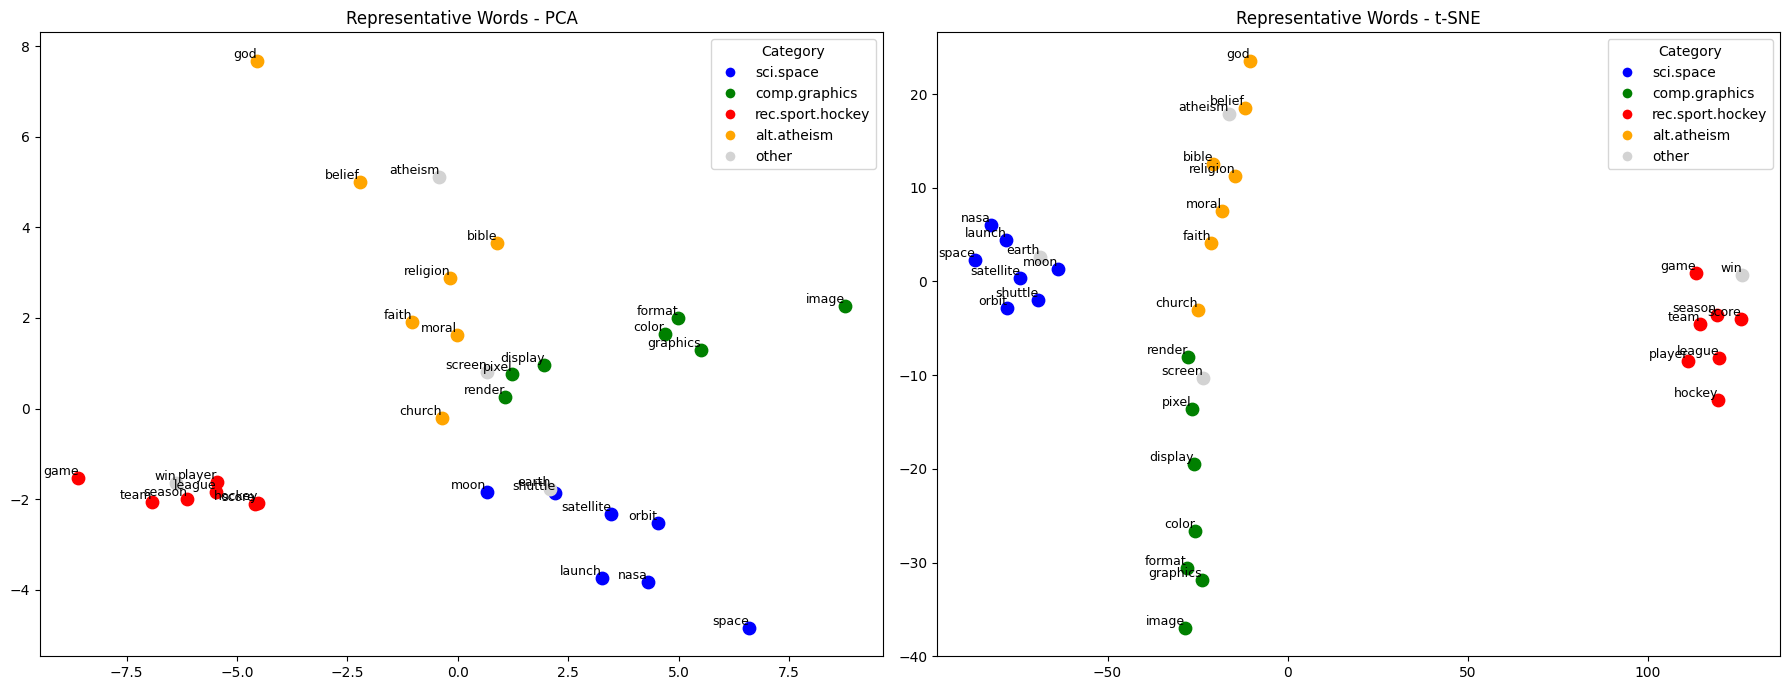

In [92]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, result, title in zip(axes, [pca_rep, tsne_rep], ["PCA", "t-SNE"]):
    for i, word in enumerate(representative_words_filtered):  # <-- use representative_words_filtered here
        cat = word_categories.get(word, 'other')
        color = color_map.get(cat, 'grey')
        ax.scatter(result[i, 0], result[i, 1], color=color, s=80, zorder=2)
        ax.annotate(word, (result[i, 0], result[i, 1]), fontsize=9, ha='right', va='bottom')

    handles = [plt.Line2D([0], [0], marker='o', color='w',
                markerfacecolor=c, markersize=8, label=l)
                for l, c in color_map.items()]
    ax.legend(handles=handles, title="Category")
    ax.set_title(f"Representative Words - {title}")

plt.tight_layout()
plt.show()